<a href="https://colab.research.google.com/github/Oscarandres2604/analysis_urban_mobility_vs_productivity/blob/main/S5_ladb_mobility_economy_project_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction

AS a data analyst your goas is **evaluate the relationship between urban mobility and economic productivity in major Latin American cities**.
To do this, you will work with real data from the TomTom Traffic Index and OECD Cities, which you must clean, combine, and analyze to identify which cities are the best candidates for investment in transport infrastructure.

## 🧩 Step 1: Load and explore

Before cleaning or combining the data, you need to **familiarize yourself with the structure of both datasets**.
At this stage, you will verify that the files load correctly, get to know their columns and data types, and detect potential inconsistencies.

### 1.1 Data loading and quick view

**🎯Goal:**
Import the necessary libraries, load the CSV files into DataFrames, and perform a preliminary review to understand their content.

**Instructions:**
- Import the libraries `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Load the files using `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Save the DataFrames in the variables `traffic` y `eco`.
- Display the first 5 rows of each DataFrame.


In [ ]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Loading files
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# show the first 5 rows of traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# Show the first 5 rows of eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Step 2: Explore, clean y prepare the data.

Before combining the datasets, inspect their structure, data types, columns, and missing values.
Note the columns that require cleaning, and then standardize the column names.

### 2.1 Explore the structure and data types

**🎯Goal:**
Identify columns with incorrect data types, distributions, and null values, and note the columns requiring conversion.

**Instructions:**

- Use `.info()` to examine the structure of both DataFrames.
- Display the first 3 rows of each DataFrame
- Determine whether the data in each DataFrame is correct or requires adjustments, and write your conclusions in the Markdown block.
  - ¿Are there any columns that require conversion? Which ones? What is their current data type, and what should it be?
  - ¿Is there any missing data in any of the columns?


In [ ]:
# Explore the traffic dataframe structure
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [ ]:
# Explore the eco dataframe structure
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


### 2.2 Rename columns

**🎯Goal:**
Standardize column names to avoid errors and facilitate merging the datasets.

**Instructions:**

- Change the column names so they follow the format `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verify that the changes have been applied correctly using `.columns`.


In [ ]:
# Standardize the traffic column names.
traffic.columns = ['country','city', 'update_time_utc','jams_delay', 'traffic_index_live', 'jams_length_kms', 'jams_count', 'traffic_index_week_ago', 'update_time_utc_week_ago', 'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins', 'mins_delay']

# Verify changes
traffic.columns

In [ ]:
# Standarize the eco column names.
eco.columns = ['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct', 'pm25', 'population_m']

# Verify changes
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Fixing numerical and date formats

**🎯Goal:**
Ensure that date and numerical columns are stored in the correct formats to allow accurate analysis, calculations, and comparisons.

**Instructions:**

- Convert the date columns in `traffic` to `datetime` format. Make the conversion error-proof
- In the `eco` dataset, clean the numerical values:
    - In `city_gdp_capita`: remove thousands separators `(.)` and replace commas (`','`) with periods (`'.'`) before converting to float.
    - En `unemployment_pct`: remove the percentage symbol (`%`) and replace commas (`','`) with periods (`'.'`) before converting to `float`.
    - In `population_m`: Replace commas (`','`) with periods (`'.'`) before converting to `float`.
- Finally, create a new column called `population` by multiplying `population_m` by 1,000,000 to obtain the total population.


In [ ]:
# Convert the traffic columns to date format using pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors = 'coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'],
                                                     errors = 'coerce')

# verify the change
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [ ]:

# Clean separators and convert numerical columns in eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%','').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].str.replace(',','.').astype(float)

# Calculate the total population in absolute units (Multiply by 1,000,000)
eco['population_m'] = eco['population_m']*1000000

# Verify the change
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.8+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13600000.0



---

## 🧩Step 3: Extract Year and Filter

Extracting the year allows us to filter the information and work only with the most recent and relevant period.

### 3.1 Extract the Year Column and Filter 2024

**🎯Goal**
Identify the year of each record and keep only the records from 2024.

**Instructions**

- Since the `traffic` DataFrame does not have a year column, use the `.dt.year` attribute on its date column to create a new column called `year`.
- Filter the rows where the year is **2024**.
- Use `.copy()` to create two new DataFrames (`traffic_2024` y `eco_2024`) to avoid modifying the original dataset.

In [ ]:
# Extract the year from the dates in update_time_utc
traffic['year'] = pd.to_datetime(traffic['update_time_utc'], errors = 'coerce').dt.year

# Verify the change
display(traffic.head(3))
traffic.info()

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 13 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [ ]:
# Filter the records for the year 2024
traffic_2024 = traffic.copy()
traffic_2024 = traffic_2024[traffic_2024['year'] == 2024]
# eco_2024
eco_2024 = eco.copy()
eco_2024 = eco_2024[eco_2024['year']== 2024]

# Review the new dataframes
display(traffic_2024.head())
display(eco_2024.head())
traffic.info()
eco.info()


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3900000.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 13 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min


---

## 🧩Step 4: Analyze and Summarize Mobility Data

Since the traffic dataset contains **multiple records per city**, in this section you will calculate annual averages by city to simplify the analysis and obtain a clearer view of overall trends.

### 4.1 Calculate Average Traffic by City

**🎯Goal:**
Obtain a consolidated view of average traffic by city and year in order to analyze general patterns without relying on daily data.

**Instructions**

- Group the data by `city`, `country` y `year`.
- Calculate the average **only for the most relevant traffic metrics**: such as `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, and travel times (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Save the result as `traffic_city_year_2024`, keeping the columns as variables rather than indexes.


<details>
<summary>Click to see the clue</summary>
Use ".agg()" to apply average functions. At the end, resets the index to keep the grouping columns as variables (not indexes).

In [ ]:

# Calculate average traffic metrics by city, country, and year.
traffic_city_year_2024 =  traffic_2024.groupby(['city', 'country', 'year'])\
    [['jams_delay', 'traffic_index_live', 'jams_length_kms','jams_count', 'mins_delay', 'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']]\
    .agg('mean').reset_index()

# Show the result
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Reflection moment**

¡Excellent work so far!

Now that you have the annual averages by city, it is time to **observe them** carefully.

Think about the following:

- ¿Which city do you think has the highest average traffic delay?
- ¿Will it be a city in **Europe**, **Latin America**, or another region of the world?

To find out, run the following line of code:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Verify which city appears at the top of the list.

Are you surprised by the results? Do they match what you expected?

In [ ]:
traffic_city_year_2024.sort_values(by = "jams_delay", ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694



---

## 🧩Step 5: Combining Mobility and Economic Dataframes

Combining datasets allows you to analyze how economic indicators relate to mobility indicators.

### 5.1 Joining traffic data (Main Table) with Economic indicators

**🎯Goal:**
Combine traffic and economic information into a single DataFrame to analyze how economic conditions relate to urban mobility.

**Instructions**
- Select only the **relevant columns** from each dataset (for example, key traffic and economic variables).
- Use `.copy()` when creating subsets to avoid modifying the original dataset.
- Join both DataFrames using `city` and `year` as the join keys.
- Keep only the cities and years that are present in both datasets.
- Save the result in a new variable called `merged` and display the first 5 rows.


In [ ]:
# Select relevant columns of traffic and eco
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population_m']

# Use .copy() to create the two new reduced datasets
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Join datasets
merged = pd.merge(traffic_2024_small, eco_2024_small , on = ['city','year'],how= 'inner')

# Show the first 5 rows
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population_m
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## 🧩Step 6: Visualizing and Analyzing Relationships

Now that you have a clean and unified dataset, it is time to **visualize patterns**.
Charts will help you understand how economic variables relate to urban mobility indicators.

### 6.1 Visualizing relationships between economic and traffic indicators

**🎯Goal:**
Visually analyze the distribution and relationship between traffic and economic indicators in 2024 to identify potential patterns or general trends between both variables.

**Instructions**
- Use the libraries `seaborn` and `matplotlib.pyplot` to generate the charts.
- Visualize the distribution of **traffic** (`jams_delay`) using:
    - **Boxplot** → to observe the mean, median, and detect outliers.
- Visualize the distribution of the **economy** (`city_gdp_capita`) using:
    - **Histogram** → to analyze the shape of the distribution and the average GDP per capita.
- Finally, **compare both variables**, to determine whether there is any relationship between them by creating a single bar chart displaying both indicators.
- Remember to add a title and axis labels to your charts.
- Observe and comment on any patterns, extreme values, or potential relationships you identify.

**Tip:** Inside the parentheses of the boxplot, add `showmeans=True` to see the average on the chart.

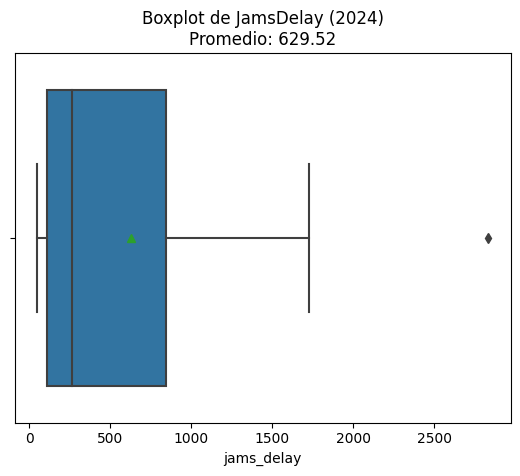

In [ ]:
# Create a boxplot to observe the behavior of congestion minutes (jams_delay)

import seaborn as sns
import matplotlib.pyplot as plt
# crea tu gráfico
sns.boxplot(data= merged, x = 'jams_delay', showmeans = True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nAverage: {mean_value:.2f}')
plt.show()



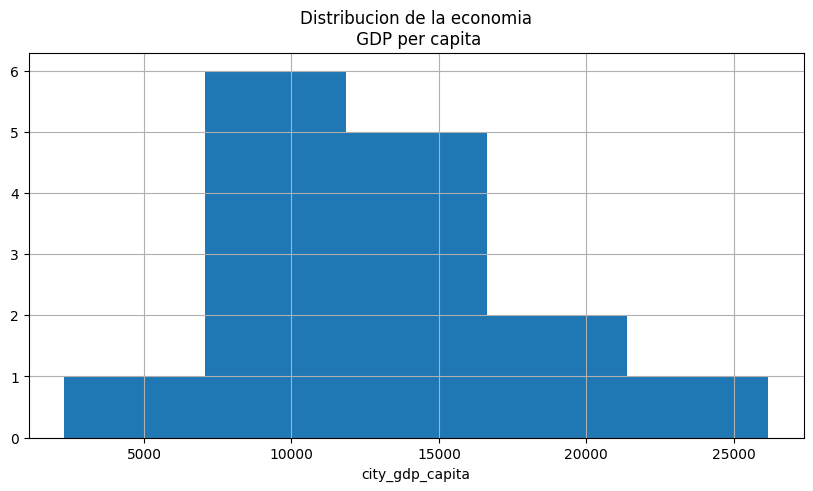

In [ ]:
# Create a histogram to visualize the distribution of the economic indicator (city_gdp_capita)
merged['city_gdp_capita'].hist(bins = 5, figsize = (10,5))
plt.title('Economic distribution\n GDP per capita')
plt.xlabel('city_gdp_capita')
plt.show()

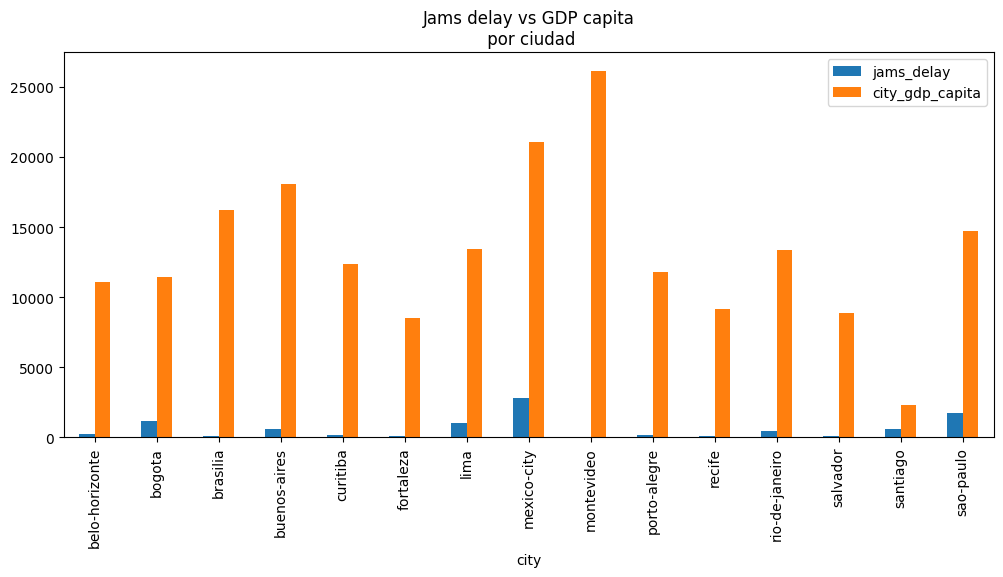

In [ ]:
# Bar chart comparing jams_delay and city_gdp_capita by city
merged.plot( kind ='bar',x = 'city', y=['jams_delay', 'city_gdp_capita'],figsize =(12,5))
plt.title('Jams delay vs GDP capita\n por ciudad')
plt.xticks(rotation=90)
plt.show()

### 🧠 **Reflect**
Excellent work reaching this stage of the analysis. Before moving forward, review your charts and take a moment to think:

* Do cities with higher GDP per capita also experience higher congestion?

* Or is the opposite true, or is there no clear relationship?

Write your comments: 'When observing the comparative chart between GDP per capita and jams_delay, no clear trend or relationship can be identified between the two variables. For example, Montevideo has a relatively high GDP per capita and an almost negligible congestion delay, while Fortaleza, with a considerably lower GDP, also records a low level of jams_delay. On the other hand, Mexico City shows the highest congestion delay, despite having the second-highest GDP per capita among the cities analyzed.'


---

## 🧩Step 7: Exporting and Documenting Results

In this final stage, you will consolidate all your work by saving the cleaned dataset and creating a summary documenting the project results.

### 7.1 Save the final dataset

**🎯Goal:**
Generate a clean, reproducible CSV file containing relevant columns for further analysis.

**Instructions**

- Export the `merged` data frame with the name: `ladb_mobility_economy_2024_clean.csv`
- Use `index=False` to prevent the index from being included.


In [ ]:
# Export the final dataset as CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

## ✅ Deliverables

1. **Notebook `.ipynb`** containing all cells (code + comments).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Brief executive summary** in markdown (3–5 párrafos).



---

# 🧾 Executive Summary (Template)

> Complete this summary after finishing the analysis. Keep it to 3–5 short, clear, and actionable paragraphs.

**Context and goal**  
- Answer the central question of the analysis: What relationship exists between urban mobility (congestion and travel times) and economic productivity (GDP per capita)?
- Briefly explain the key variables used and their relevance for decision-making.

**Data coverage:**  
- Specify the analyzed years and the number of cities and countries included.

**Methodology (high level):**  
- Describe the main processes: data cleaning (formats and column standardization).
- Explain the city-year aggregation and the use of an INNER JOIN to integrate traffic and economic data.
- Mention the visual validations used (distributions, outliers, and general trends).

**Initial findings:**  
- Summarize the most important patterns between traffic indicators and GDP per capita.
- Highlight anomalies or outliers that may require further review or deeper analysis.

**Recommendations**  
Translate the findings into actionable steps: priority cities, the need to validate data sources, additional analysis requirements, or potential investment proposals.

- ¿Which city: Bogotá, Lima, Buenos Aires, or another city in particular shows the strongest significant correlation between high levels of traffic congestion and low economic productivity indicators, suggesting that it should be prioritized for transportation infrastructure investment?


In [ ]:
#Urban mobility and economic productivity analysis in LATAM Cities

##Data preparation

The tomtom_traffic.csv and oecd_city_economy.csv datasets were reviewed and cleaned, including data types, numerical formats, and date formats. The year 2024 was extracted from the traffic dataset because the source DataFrame contained complete date values. The necessary variables were also standardized to ensure data consistency.
Due to the large number of traffic measurements, the data was grouped by country, city, and year, calculating the averages of the required variables.
The information was then filtered for 2024, and the traffic_2024_small and eco_2024_small datasets were created.

##Data integration and visualization

Both datasets were joined using pd.merge(), with city and year as the join keys and an INNER JOIN, resulting in the final merged DataFrame.
Several visualizations were then created, including boxplots, histograms, and comparative bar charts.

##key findings

The analysis showed an average jams_delay of 629.52 minutes, while GDP per capita for most cities was concentrated between approximately $7,000 and $12,000.

An outlier was also identified in the boxplot analysis of jams_delay, with a value above 2,500 minutes. This value could potentially be due to an error in the corresponding data column or could represent a significantly longer period of traffic congestion compared with the average.

However, after analyzing the data, the comparative chart did not reveal a clear relationship between traffic congestion levels and economic productivity among the LATAM cities analyzed. The cities included were:

-Belo Horizonte
-Bogotá
-Brasília
-Buenos Aires
-Curitiba
-Fortaleza
-Lima
-Mexico City
-Montevideo
-Porto Alegre
-Recife
-Rio de Janeiro
-Salvador
-Santiago
-Sao Paulo.

##Recommendations

As a recommendation, the analysis could be complemented with additional variables such as population, urban density, unemployment, road infrastructure, and travel times. This would allow a more comprehensive assessment of the factors that may explain differences in productivity across cities and could provide a stronger basis for urban mobility decision-making.


"Análisis de movilidad urbana y productividad económica en ciudades de LATAM'\n\nSe verificaron y limpiaron los datasets tomtom_traffic.csv y oecd_city_economy.csv, revisando tipos de datos, \nformatos numéricos y fechas. Se extrajo el año 2024 en el dataset traffic porque en el frame origen la fecha venia en formato\nde fecha completa, tambien se estandarizaron las variables necesarias para garantizar la consistencia de la información.\n\nDebido a la gran cantidad de mediciones de tráfico, los datos se agruparon por país, ciudad y año, calculando los promedios de las variables requeridas. \nPosteriormente, se filtró la información de 2024 y se generaron los datasets traffic_2024_small y eco_2024_small.\n\nAmbos datasets fueron unidos mediante pd.merge() utilizando como claves ciudad y año, con tipo de unión inner, obteniendo el DataFrame final merged. \nA partir de este se realizaron diferentes visualizaciones, entre ellas boxplots, histogramas y gráficos de barras comparativos.\n\nEl